In [1]:
# import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_squared_error, r2_score,
    accuracy_score, precision_score, recall_score, f1_score,
    precision_recall_curve, confusion_matrix, ConfusionMatrixDisplay
)

In [2]:
# define file paths
paths = {
    'county_claims': '../data/processed/selected_county_claims.csv',
    'profiling_table': '../output/profiling_table.csv',
    'model_data': '../data/processed/cleaned_model_data.csv'
    }
# paths['output_graph1'] = '../output/


In [3]:
# import data
df = pd.read_csv(paths['county_claims'])

/var/folders/0q/ndh_pk0s37n95y6svtjfy7hw0000gp/T/ipykernel_51902/1829000608.py:2: DtypeWarning: Columns (0: causeOfDamage) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(paths['county_claims'])


In [4]:
df.head()

,agricultureStructureIndicator,asOfDate,basementEnclosureCrawlspaceType,policyCount,crsClassificationCode,dateOfLoss,elevatedBuildingIndicator,elevationCertificateIndicator,elevationDifference,baseFloodElevation,...,rentalPropertyIndicator,state,reportedCity,reportedZipCode,countyCode,censusTract,censusBlockGroupFips,latitude,longitude,id
0,False,2026-02-11 00:00:00+00:00,NaN,1,NaN,1996-09-05,False,NaN,NaN,NaN,...,False,NC,Currently Unavailable,27810.0,37013,3.701393e+10,3.701393e+11,35.5,-76.6,069b717f-4be7-4a39-b86c-856ed210869c
1,False,2026-02-11 00:00:00+00:00,NaN,1,NaN,1998-08-26,False,NaN,NaN,NaN,...,False,NC,Currently Unavailable,27810.0,37013,3.701393e+10,3.701393e+11,35.5,-76.6,a094b0f5-7e81-4606-916d-e1427026b4e9
2,False,2026-02-11 00:00:00+00:00,NaN,1,NaN,1999-09-16,False,NaN,3.0,119.5,...,False,NC,Currently Unavailable,27801.0,37065,3.706502e+10,3.706502e+11,35.9,-77.8,d8fc0653-9392-49a8-81ba-19f4272df92a
3,False,2026-02-11 00:00:00+00:00,NaN,1,NaN,2016-10-09,True,NaN,-2.0,35.0,...,False,NC,Currently Unavailable,28501.0,37107,3.710701e+10,3.710701e+11,35.3,-77.6,6d61a117-df44-4a51-b940-cdffe5bf480c
4,False,2026-02-11 00:00:00+00:00,NaN,1,NaN,2011-08-27,False,NaN,NaN,NaN,...,False,NC,Currently Unavailable,27810.0,37013,3.701393e+10,3.701393e+11,35.5,-76.6,282c05ff-a5cc-4cdf-a9c9-5fe42c2737cb


### Data Inspection

In [5]:
# data inspection
print(f'Raw data shape: {df.shape}')

profile_table = pd.DataFrame({
    "col_name": df.columns,
    "dtype": df.dtypes,
    "n_missing": [df[col].isna().sum() for col in df.columns],
    "missing_rate": [round(df[col].isna().mean()*100, 2) for col in df.columns],
    "is_unique": df.columns.duplicated(),
    "n_unique": [df[col].nunique() for col in df.columns],
    "sample_values": [list(df[col].unique()[0:3]) for col in df.columns]
}).set_index("col_name")
profile_table.to_csv(paths['profiling_table'])
profile_table

Raw data shape: (13712, 73)


,dtype,n_missing,missing_rate,is_unique,n_unique,sample_values
col_name,,,,,,
agricultureStructureIndicator,bool,0,0.00,False,2,"[False, True]"
asOfDate,str,0,0.00,False,1,[2026-02-11 00:00:00+00:00]
basementEnclosureCrawlspaceType,float64,11138,81.23,False,4,"[nan, 2.0, 0.0]"
policyCount,int64,0,0.00,False,4,"[1, 8, 2]"
crsClassificationCode,float64,13133,95.78,False,3,"[nan, 7.0, 8.0]"
...,...,...,...,...,...,...
censusTract,float64,551,4.02,False,116,"[37013930700.0, 37013930100.0, 37065020400.0]"
censusBlockGroupFips,float64,551,4.02,False,285,"[370139307001.0, 370139301005.0, 370650204004.0]"
latitude,float64,0,0.00,False,17,"[35.5, 35.9, 35.3]"


### Data Cleaning & Feature Engineering

| Issue | Decision |
|-------|----------|
| Null claim amounts (13.4%) | Drop — no Y value means unusable |
| Y variable right-skewed | log1p transform |
| Bad construction dates (e.g. 1492) | Clip to 1800–2025 |
| ratedFloodZone 26 categories | Simplify: High/Moderate/Low/Possible |
| Unknown flood zone (521 rows) | Drop — not a real risk category |
| waterDepth nulls | Fill with median, clip at P99=49ft |
| Rare flood events (<20 samples) | Merge into 'Other' |

In [6]:
# 1. Drop rows without claim amount
df = df.dropna(subset=['amountPaidOnBuildingClaim'])
print(f'After dropping null claims: {len(df)} rows')

# 2. Parse year_built, compute building_age
df['year_built'] = pd.to_datetime(df['originalConstructionDate'], errors='coerce').dt.year
df['year_built'] = df['year_built'].clip(lower=1800, upper=2025)
df['building_age'] = df['yearOfLoss'] - df['year_built']
df['building_age'] = df['building_age'].clip(lower=0)

# 3. Simplify flood zone
def simplify_flood_zone(zone):
    if pd.isna(zone):
        return 'Unknown'
    zone = str(zone).strip().upper()
    if zone.startswith('V') or zone.startswith('A') or zone.startswith('AR'):
        return 'High'
    elif zone == 'D':
        return 'Possible'
    elif zone in ['B', 'X']:
        return 'Moderate'
    elif zone == 'C':
        return 'Low'
    else:
        return 'Unknown'

df['flood_zone_simple'] = df['ratedFloodZone'].apply(simplify_flood_zone)

# Drop Unknown zone rows
df = df[df['flood_zone_simple'] != 'Unknown'].reset_index(drop=True)
print(f'After dropping Unknown zone: {len(df)} rows')
print('Flood zone distribution:')
print(df['flood_zone_simple'].value_counts())

# 4. Fill waterDepth nulls, clip at P99
median_depth = df['waterDepth'].median()
df['waterDepth'] = df['waterDepth'].fillna(median_depth)
df['waterDepth'] = df['waterDepth'].clip(upper=49)
print(f'\nwaterDepth median: {median_depth:.1f} ft, clipped at 49 ft')

# 5. Merge rare flood events (<20 samples) into 'Other'
df['floodEvent'] = df['floodEvent'].fillna('Unknown')
event_counts = df['floodEvent'].value_counts()
df['floodEvent'] = df['floodEvent'].apply(
    lambda x: x if event_counts[x] >= 20 else 'Other'
)
print('\nFlood event distribution after merging small samples:')
print(df['floodEvent'].value_counts())

# 6. Encode binary/indicator variables
df['is_residential']   = df['occupancyType'].isin([1,2,11,12,13,14]).astype(int)
df['elevated']         = df['elevatedBuildingIndicator'].astype(int)
df['post_firm']        = df['postFIRMConstructionIndicator'].astype(int)
df['primary_residence']= df['primaryResidenceIndicator'].astype(int)

# 7. Dummy variables
zone_dummies   = pd.get_dummies(df['flood_zone_simple'], prefix='zone',   drop_first=True)
county_dummies = pd.get_dummies(df['countyCode'],        prefix='county', drop_first=True)
event_dummies  = pd.get_dummies(df['floodEvent'],        prefix='event',  drop_first=True)

After dropping null claims: 11874 rows
After dropping Unknown zone: 11353 rows
Flood zone distribution:
flood_zone_simple
High        10141
Moderate     1107
Low           105
Name: count, dtype: int64

waterDepth median: 1.0 ft, clipped at 49 ft

Flood event distribution after merging small samples:
floodEvent
Hurricane Florence        1817
Hurricane Floyd           1679
Hurricane Irene           1482
Hurricane Matthew         1452
Hurricane Dennis          1048
Hurricane Fran            1015
Hurricane Bonnie           903
Unknown                    637
Hurricane Isabel           614
Hurricane Bertha           369
Tropical Storm Ophelia      97
Other                       94
Hurricane Debby             58
Tropical Storm Ernesto      47
Hurricane Eta               41
Name: count, dtype: int64


### Prep Data for Modeling
Features: 
- **Numerial**: 'waterDepth', 'building_age', 'totalBuildingInsuranceCoverage'
- **Binary**: 'elevated', 'post_firm', 'is_residential', 'primary_residence'
- **Catagorical**: 'flood_zone_simple', 'countyCode', 'floodEvent'

In [7]:
continuous_features = [
    'waterDepth',
    'building_age',
    'totalBuildingInsuranceCoverage',
]

binary_features = [
    'elevated',
    'post_firm',
    'is_residential',
    'primary_residence',
]

df = df.reset_index(drop=True)

X = pd.concat([
    df[continuous_features + binary_features].reset_index(drop=True),
    zone_dummies.reset_index(drop=True),
    county_dummies.reset_index(drop=True),
    event_dummies.reset_index(drop=True)
], axis=1)

# Drop rows with any remaining nulls
mask = X.notna().all(axis=1)
X = X[mask].reset_index(drop=True)
df_clean = df[mask].reset_index(drop=True)

# change column value to 0/1 for binary features
for col in X.columns:
    if X[col].nunique() == 2:
        X[col] = X[col].astype(int)

print(f'Final dataset: {len(X)} rows, {X.shape[1]} features')

Final dataset: 11353 rows, 27 features


In [8]:
# inspection for cleaned dataset
Xprofile_table = pd.DataFrame({
    "col_name": X.columns,
    "dtype": X.dtypes,
    "n_missing": [X[col].isna().sum() for col in X.columns],
    "missing_rate": [round(X[col].isna().mean()*100, 2) for col in X.columns],
    "is_unique": X.columns.duplicated(),
    "n_unique": [X[col].nunique() for col in X.columns],
    "sample_values": [list(X[col].unique()[0:3]) for col in X.columns]
}).set_index("col_name")

Xprofile_table

,dtype,n_missing,missing_rate,is_unique,n_unique,sample_values
col_name,,,,,,
waterDepth,float64,0,0.0,False,61,"[1.0, 8.0, 2.0]"
building_age,int64,0,0.0,False,131,"[27, 5, 41]"
totalBuildingInsuranceCoverage,int64,0,0.0,False,1390,"[22000, 118500, 250000]"
elevated,int64,0,0.0,False,2,"[0, 1]"
post_firm,int64,0,0.0,False,2,"[0, 1]"
is_residential,int64,0,0.0,False,2,"[1, 0]"
primary_residence,int64,0,0.0,False,2,"[0, 1]"
zone_Low,int64,0,0.0,False,2,"[0, 1]"
zone_Moderate,int64,0,0.0,False,2,"[0, 1]"


In [9]:
# Model A target: log1p(claim amount)
y_A = np.log1p(df_clean['amountPaidOnBuildingClaim'])

# Model B target: above median = high loss (1), below = low loss (0)
median_claim = df_clean['amountPaidOnBuildingClaim'].median()
y_B = (df_clean['amountPaidOnBuildingClaim'] > median_claim).astype(int)

print(f'Median threshold: ${median_claim:,.0f}')
print(f'\nModel A (log claim amount):')
print(f'  Mean: {y_A.mean():.2f}, Std: {y_A.std():.2f}, Range: [{y_A.min():.1f}, {y_A.max():.1f}]')
print(f'\nModel B (high/low loss):')
print(f'  High loss (1): {y_B.sum()} ({y_B.mean()*100:.1f}%)')
print(f'  Low loss  (0): {(y_B==0).sum()} ({(y_B==0).mean()*100:.1f}%)')

Median threshold: $8,743

Model A (log claim amount):
  Mean: 8.89, Std: 1.98, Range: [0.0, 13.1]

Model B (high/low loss):
  High loss (1): 5676 (50.0%)
  Low loss  (0): 5677 (50.0%)


In [10]:
# combine X and y for as cleaned modeling data
df_model = pd.concat([X, y_A.rename('log_claim'),y_B.rename('high_loss')], axis=1)

df_model.to_csv(paths['model_data'], index=False)
df_model

,waterDepth,building_age,totalBuildingInsuranceCoverage,elevated,post_firm,is_residential,primary_residence,zone_Low,zone_Moderate,county_37065,...,event_Hurricane Fran,event_Hurricane Irene,event_Hurricane Isabel,event_Hurricane Matthew,event_Other,event_Tropical Storm Ernesto,event_Tropical Storm Ophelia,event_Unknown,log_claim,high_loss
0,1.0,27,22000,0,0,1,0,0,0,0,...,1,0,0,0,0,0,0,0,9.729842,1
1,8.0,5,118500,0,1,1,1,0,0,1,...,0,0,0,0,0,0,0,0,11.346905,1
2,1.0,41,250000,1,0,1,0,0,0,0,...,0,0,0,1,0,0,0,0,10.107731,1
3,2.0,47,320600,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,7.489188,0
4,0.0,22,250000,1,1,1,1,0,0,0,...,0,1,0,0,0,0,0,0,9.730266,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11348,0.0,100,21000,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,9.162146,1
11349,3.0,22,250000,1,1,1,1,0,0,0,...,0,0,0,1,0,0,0,0,11.125782,1
11350,0.0,24,120900,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,9.105048,1
11351,1.0,60,103000,1,0,1,1,0,0,0,...,0,0,0,1,0,0,0,0,10.569212,1


### EDA

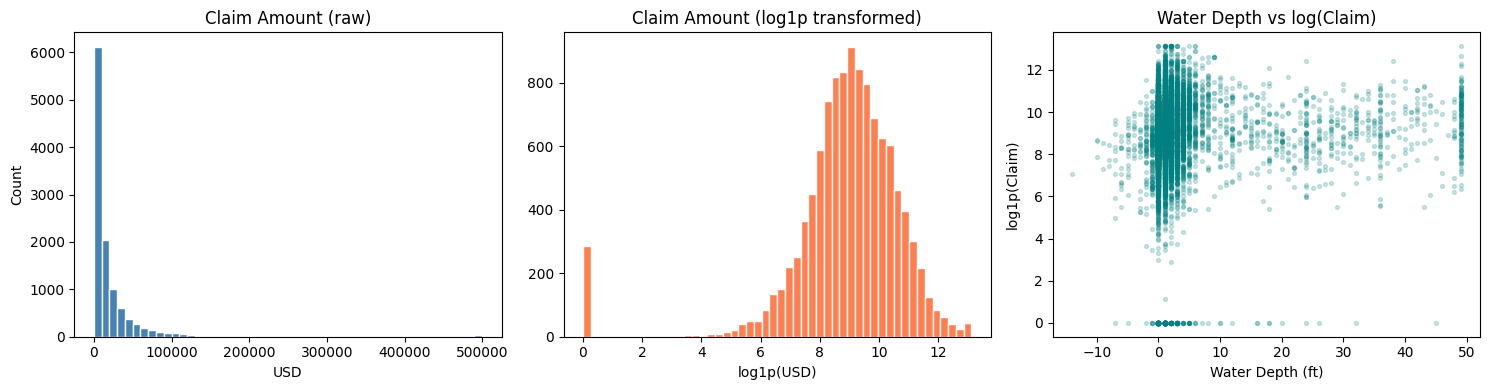

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(df_clean['amountPaidOnBuildingClaim'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Claim Amount (raw)'); axes[0].set_xlabel('USD'); axes[0].set_ylabel('Count')

axes[1].hist(y_A, bins=50, color='coral', edgecolor='white')
axes[1].set_title('Claim Amount (log1p transformed)'); axes[1].set_xlabel('log1p(USD)')

axes[2].scatter(df_clean['waterDepth'], y_A, alpha=0.2, s=8, color='teal')
axes[2].set_title('Water Depth vs log(Claim)')
axes[2].set_xlabel('Water Depth (ft)'); axes[2].set_ylabel('log1p(Claim)')

plt.tight_layout(); plt.show()

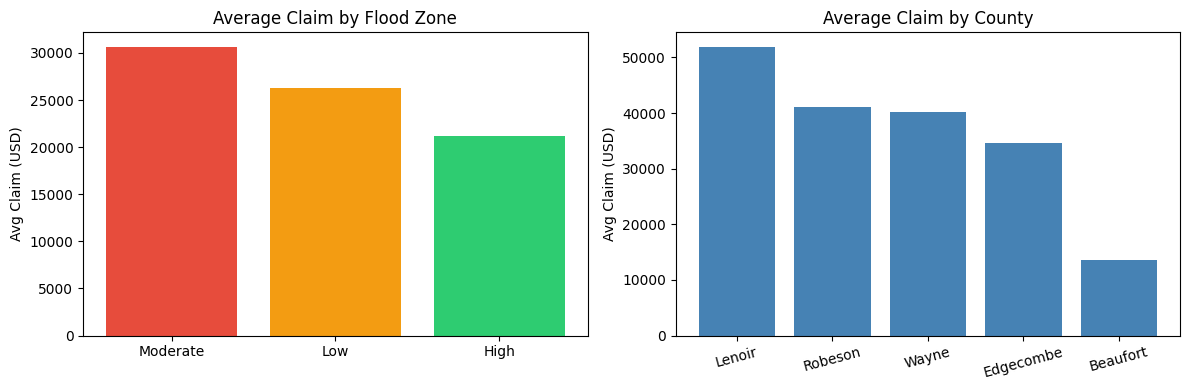

In [27]:
# raw claim amount distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

avg_by_event = df_clean.groupby('flood_zone_simple')['amountPaidOnBuildingClaim'].mean().sort_values(ascending=False)
axes[0].bar(avg_by_event.index, avg_by_event.values, color=['#e74c3c','#f39c12','#2ecc71','#95a5a6'])
axes[0].set_title('Average Claim by Flood Zone'); axes[0].set_ylabel('Avg Claim (USD)')

county_names = {37013:'Beaufort',37065:'Edgecombe',37107:'Lenoir',37155:'Robeson',37191:'Wayne'}
df_clean['county_name'] = df_clean['countyCode'].map(county_names)
avg_by_county = df_clean.groupby('county_name')['amountPaidOnBuildingClaim'].mean().sort_values(ascending=False)
axes[1].bar(avg_by_county.index, avg_by_county.values, color='steelblue')
axes[1].set_title('Average Claim by County'); axes[1].set_ylabel('Avg Claim (USD)')
axes[1].tick_params(axis='x', rotation=15)


plt.tight_layout(); plt.show()

/var/folders/0q/ndh_pk0s37n95y6svtjfy7hw0000gp/T/ipykernel_51902/3507231696.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


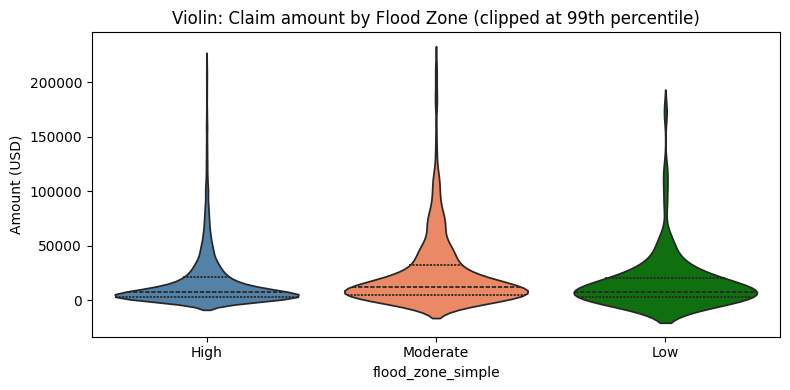

In [13]:
# Violin plot for raw claim amounts (clipped at 99th percentile)
col = 'amountPaidOnBuildingClaim'
p99 = df_clean[col].quantile(0.99)
fig, ax = plt.subplots(figsize=(8,4))
sns.violinplot(
    x='flood_zone_simple',
    y=col,
    data=df_clean[df_clean[col] <= p99],
    inner='quartile',
    palette={'High':'steelblue','Moderate':'coral','Low':'green'},
    ax=ax
)
ax.set_title('Violin: Claim amount by Flood Zone (clipped at 99th percentile)')
ax.set_ylabel('Amount (USD)')
plt.tight_layout(); plt.show()